# Lecture 10c — KNN decision boundaries

You have already built a KNN classifier (lec_10a) and seen the failure modes (lec_10b). This notebook closes the core arc with the **geometric intuition**: what does the model actually do when it classifies a new point? The answer is a *decision boundary* — a line (or a set of curves) in feature space that splits the plane into regions, one region per predicted class.

If you can picture the boundary, you can predict how the model will behave on data you have not seen yet. That is the single most useful mental model for KNN.

## What this notebook covers

- Plot the iris training data on a 2-feature slice (sepal length × sepal width).
- Overlay the KNN decision boundary on the same axes using a mesh-grid trick.
- Contrast `weights="uniform"` and `weights="distance"` on identical data — the boundary changes shape.
- Sweep `n_neighbors` across K=1, 5, 15, 50 and watch the boundary go from jagged to smooth.

## What you should already know

- The KNN pipeline from `lec_10a_knn_classification.ipynb` (`fit`, `predict`, accuracy).
- The four KNN failure modes from `lec_10b_knn_assumptions_caveats.ipynb` — especially that scaling matters. We work in raw centimetres here for visual clarity; do *not* skip scaling on a production pipeline.


In [1]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier

RANDOM_STATE = 42


## 1. The dataset — a 2-feature slice of iris

For the boundary to be drawable on paper, we need exactly two features. We take the first two columns of iris (sepal length, sepal width). These two features happen to *overlap* between species — sepal-based classification is harder than petal-based — which makes the boundary interesting to look at.


In [2]:
iris = datasets.load_iris()
X = iris.data[:, :2]  # sepal length, sepal width — first two columns only
y = iris.target
target_names = iris.target_names

print(f"X shape: {X.shape}  (150 flowers, 2 features)")
print(f"Classes:  {dict(enumerate(target_names))}")


X shape: (150, 2)  (150 flowers, 2 features)
Classes:  {0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}


### Look at the labelled data first

Before drawing any boundary, just plot the points. Each colour is one species. Notice how setosa (red) is cleanly separated, while versicolor (green) and virginica (blue) overlap heavily on these two features — KNN will have to commit to *some* boundary in that overlap region.


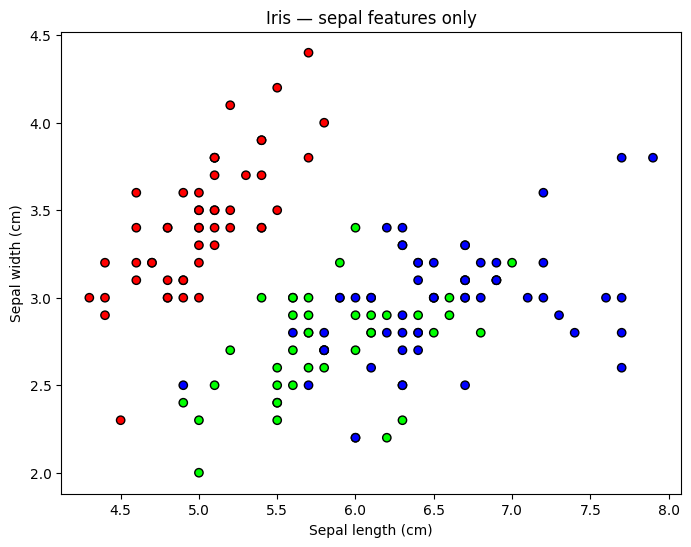

In [3]:
cmap_points = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_points, edgecolors='k')
plt.xlabel('Sepal length (cm)')
plt.ylabel('Sepal width (cm)')
plt.title('Iris — sepal features only')
plt.show()


## 2. The mesh-grid trick — how we draw the boundary

We can't ask the model "where is the boundary?" directly. Scikit-learn only knows `predict(x)`: given one point, return one class. So we make a fine grid covering the whole plot area, ask the model for the prediction at every grid point, and colour the plane by those predictions. The boundaries between colour regions are the decision boundaries.

The helper below wraps this pattern so we can reuse it for each comparison.


In [4]:
cmap_regions = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])


def plot_knn_boundary(X, y, n_neighbors, weights, ax=None, title=None):
    """Fit a KNN classifier and plot the decision regions on a 2D feature slice.

    X must have exactly 2 columns. The mesh resolution is 0.02 cm.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5))

    clf = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights)
    clf.fit(X, y)

    h = 0.02  # mesh step size
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict the class for every point on the mesh.
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.pcolormesh(xx, yy, Z, cmap=cmap_regions, shading='auto')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_points, edgecolors='k', s=30)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel('Sepal length (cm)')
    ax.set_ylabel('Sepal width (cm)')
    if title is None:
        title = f"K = {n_neighbors}, weights = '{weights}'"
    ax.set_title(title)
    return clf


## 3. `weights="uniform"` — all K neighbours vote equally

With `weights="uniform"` (the default), the K nearest neighbours all get one vote each. The boundary tends to be a piecewise-linear shape — every region is convex, with corners at the midpoints between training points of different classes.


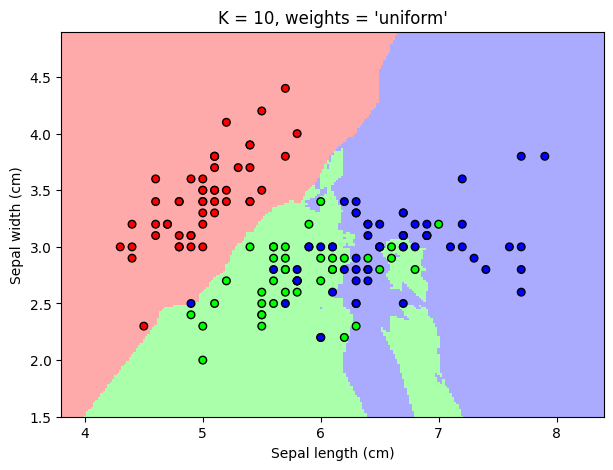

In [5]:
plot_knn_boundary(X, y, n_neighbors=10, weights='uniform')
plt.show()


## 4. `weights="distance"` — closer neighbours count more

With `weights="distance"`, each of the K neighbours' votes is divided by its distance to the query point. Close neighbours dominate the vote, distant ones barely contribute. The boundary becomes more *responsive* to local structure: it can wrap around individual outlier training points instead of cleanly averaging them out.

Compare to the uniform-weight plot above. The class regions are the same in the cleanly-separated part of the plot (setosa is still cleanly setosa), but the boundary in the overlap region between versicolor and virginica is shaped differently — more sensitive to where individual training points sit.


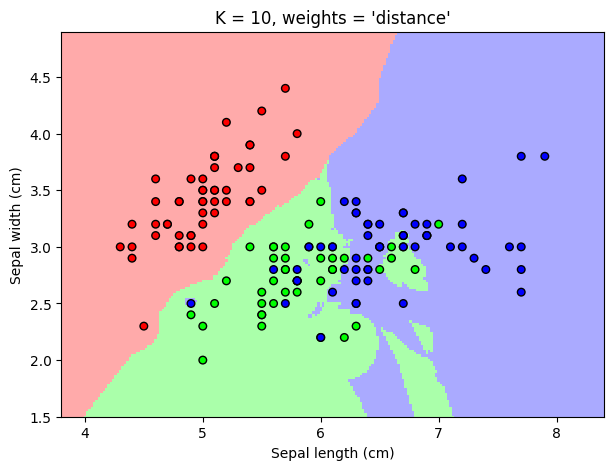

In [6]:
plot_knn_boundary(X, y, n_neighbors=10, weights='distance')
plt.show()


> ⏱ **Skip if running long.** The side-by-side comparison cell below visually reinforces what §3 and §4 already showed individually — uniform on the left, distance on the right. If you have already discussed both, skipping this combined plot is safe and saves ~2 minutes.


### Side-by-side: the same K, two weight rules

Same data, same K, two different boundary shapes. Neither is "better" in general — distance-weighting helps when the local density of the classes varies, hurts when training data is noisy (each outlier gets disproportionate pull).


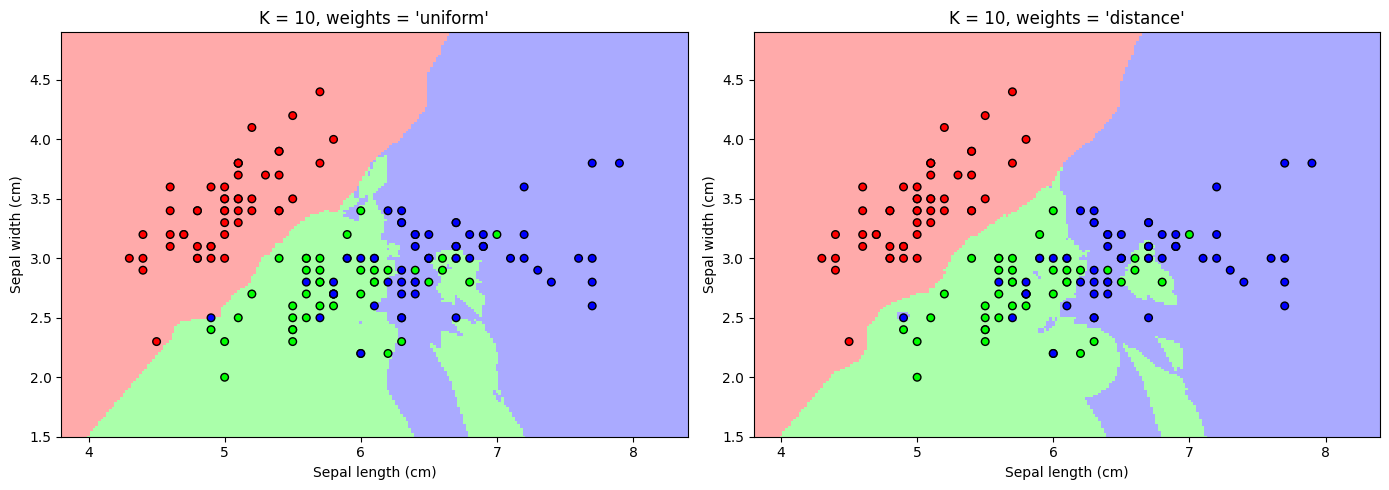

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_knn_boundary(X, y, n_neighbors=10, weights='uniform', ax=axes[0])
plot_knn_boundary(X, y, n_neighbors=10, weights='distance', ax=axes[1])
plt.tight_layout()
plt.show()


> ⏱ **Skip if running long.** The 2×2 K-sweep subplot below (§5) shows the boundary at K = 1, 5, 15, 50. The K=1 and K=50 panels are the load-bearing "over-fit" and "under-fit" anchors; the middle two (K=5, K=15) are intermediate illustrations. If short on time, show only the K=1 and K=50 panels and reference the others as at-home reading.


## 5. How `K` controls boundary smoothness

The single most important hyperparameter is `K = n_neighbors`. Walk through these four panels and watch the boundary go from jagged (over-fitting to individual training points) to smooth (under-fitting, ignoring local structure):

- **K = 1** — the model memorises every training point. Each region is a Voronoi cell around one point. Maximum complexity, maximum over-fitting.
- **K = 5** — averaging starts to suppress single-point noise. Local structure is visible but cleaner.
- **K = 15** — smooth boundaries, mostly tracking the bulk of each class.
- **K = 50** — almost a third of the training set votes on every prediction. The boundary collapses toward a simple split; the minority class is at risk of being out-voted everywhere.

This is the visual version of the train-vs-test accuracy curve you plotted in `lec_10a`. The "sweet spot" in that plot corresponds to one of these panels — usually somewhere between K=5 and K=15.


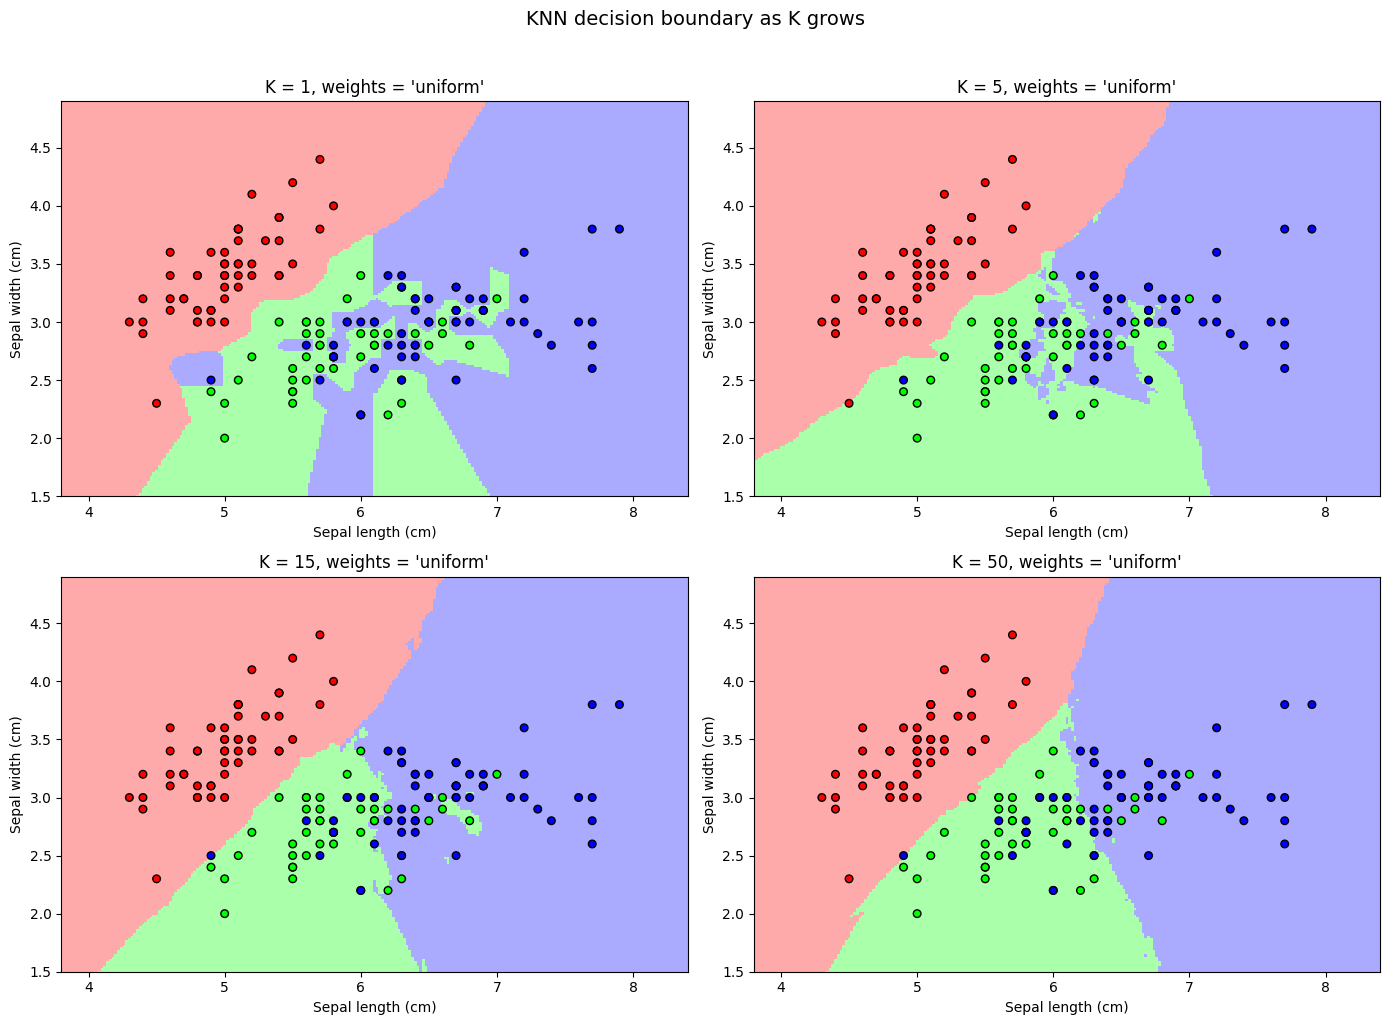

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, k in zip(axes.flat, [1, 5, 15, 50]):
    plot_knn_boundary(X, y, n_neighbors=k, weights='uniform', ax=ax)
plt.suptitle('KNN decision boundary as K grows', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## 6. Recap and what's next

- The decision boundary is a *picture* of the model. If you can see it, you can predict the model's behaviour.
- `weights="uniform"` produces piecewise-linear boundaries; `weights="distance"` produces locally-responsive boundaries.
- Small K → jagged, over-fit; large K → smooth, under-fit. The sweet spot is the K with the best test accuracy (lec_10a §B4).

**What this notebook deliberately leaves for later:**

- The remaining `KNeighborsClassifier` parameters (`metric`, `p`, `algorithm`, `leaf_size`) — see `lec_10d_knn_other_parameters.ipynb` (optional). Some of these change the boundary shape further; some only affect runtime.
- Other classifiers' boundaries for comparison — see `lec_10e_knn_vs_other_classifiers.ipynb` (optional) and lectures 11–12. Logistic regression has a single straight line; SVM with an RBF kernel curves; decision trees produce axis-aligned rectangles.

**Quick self-check:** without re-running the K-sweep above, predict what happens to the boundary if you set K = 150 (the entire training set). Then run it and see whether your prediction matched.
